In [47]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Q01


In [48]:
img = Image.open(r"C:\Ali\Programming\DlpSpring26\A01\dog.jpg")
img_array = np.array(img)
np.save(r"C:\Ali\Programming\DlpSpring26\A01\dog.npy", img_array)
print("dog.jpg converted to dog.npy")


dog.jpg converted to dog.npy


In [49]:
image = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog.npy").astype(np.float32)
mean = 0
std_dev = 15
noise = np.random.normal(mean, std_dev, image.shape)
noisy_image = image + noise
noisy_image = np.clip(noisy_image, 0, 255)
noisy_image = noisy_image.astype(np.uint8)

np.save(r"C:\Ali\Programming\DlpSpring26\A01\dog_noisy.npy", noisy_image)
print("Gaussian noise added and saved as dog_noisy.npy")


noisy_pil = Image.fromarray(noisy_image)
noisy_pil.save(r"C:\Ali\Programming\DlpSpring26\A01\dog_noisy.jpg")

print("dog_noisy.npy converted to dog_noisy.jpg")

Gaussian noise added and saved as dog_noisy.npy
dog_noisy.npy converted to dog_noisy.jpg


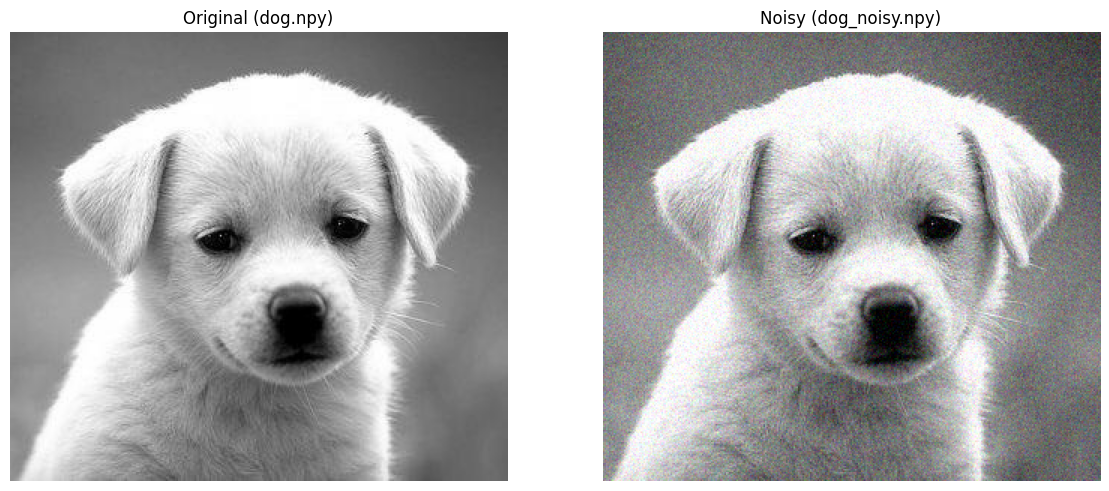

In [50]:
original = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog.npy")
noisy = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog_noisy.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original)
axes[0].set_title("Original (dog.npy)")
axes[0].axis("off")

axes[1].imshow(noisy)
axes[1].set_title("Noisy (dog_noisy.npy)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Q02

In [51]:
image = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog.npy").astype(np.float32)

if len(image.shape) == 3:
    image = image.mean(axis=2)

image = image.astype(np.float32)


kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]])


kernel_flipped = np.flipud(np.fliplr(kernel))

pad_size = kernel.shape[0] // 2   

padded_image = np.pad(image,
                      pad_width=pad_size,
                      mode='constant',
                      constant_values=0)

output = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        region = padded_image[i:i+3, j:j+3]
        multiplied = region * kernel_flipped
        output[i, j] = np.sum(multiplied)

np.save(r"C:\Ali\Programming\DlpSpring26\A01\dog_convolved.npy", output)

print("Convolution completed.")
print("Output saved as dog_convolved.npy")

Convolution completed.
Output saved as dog_convolved.npy


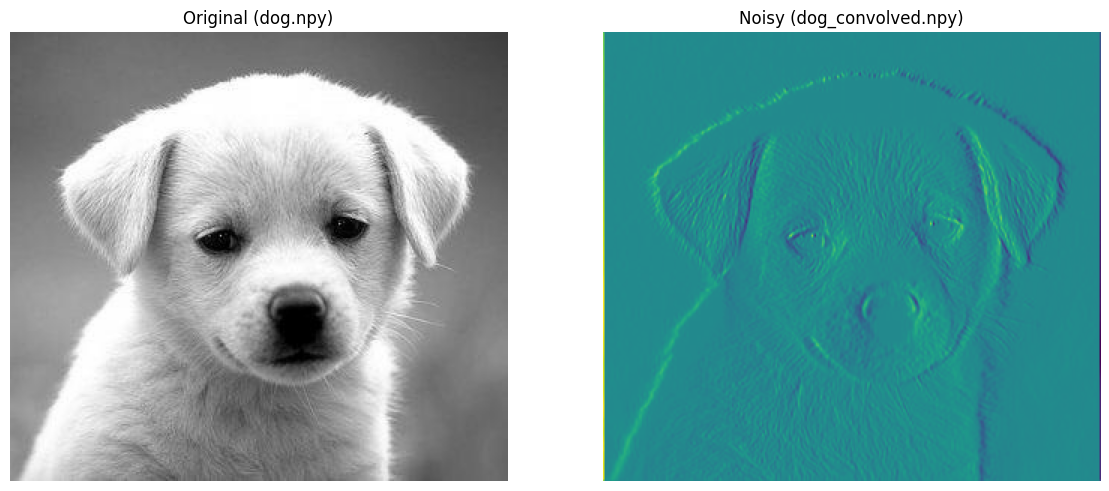

In [52]:
original = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog.npy")
noisy = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog_convolved.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original)
axes[0].set_title("Original (dog.npy)")
axes[0].axis("off")

axes[1].imshow(noisy)
axes[1].set_title("Noisy (dog_convolved.npy)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Q03

In [53]:
noisy_image = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog_noisy.npy").astype(np.float32)


if len(noisy_image.shape) == 3:
    noisy_image = noisy_image.mean(axis=2)



def gaussian_kernel(size=7, sigma=1.0):         
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)  
    return kernel

gaussian7 = gaussian_kernel(7, sigma=1.0)



def convolve2d(image, kernel):
    kernel = np.flipud(np.fliplr(kernel))

    pad_size = kernel.shape[0] // 2
    padded = np.pad(image, pad_size, mode='constant', constant_values=0)

    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            output[i, j] = np.sum(region * kernel)
    return output



denoised_image = convolve2d(noisy_image, gaussian7)
np.save(r"C:\Ali\Programming\DlpSpring26\A01\dog_denoised.npy", denoised_image)
print("Denoised image saved as dog_denoised.npy")


sharpening_kernel = np.array([
    [1, 4, 6, 4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, -476, 24, 6],
    [4, 16, 24, 16, 4],
    [1, 4, 6, 4, 1]
], dtype=np.float32) * (-1.0 / 256.0)

sharpened_image = convolve2d(denoised_image, sharpening_kernel)
np.save(r"C:\Ali\Programming\DlpSpring26\A01\dog_sharpened.npy", sharpened_image)
print("Sharpened image saved as dog_sharpened.npy")

Denoised image saved as dog_denoised.npy
Sharpened image saved as dog_sharpened.npy


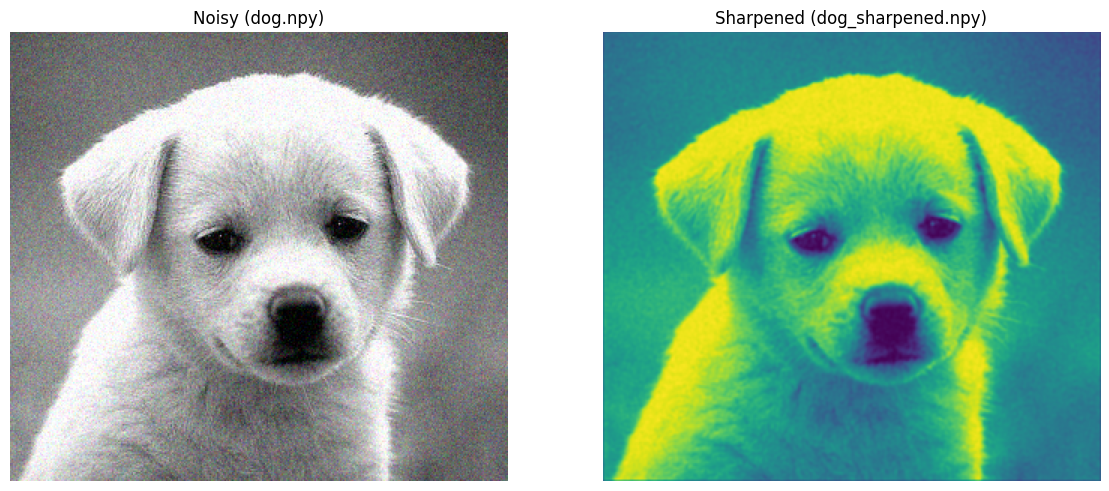

In [54]:
original = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog_noisy.npy")
noisy = np.load(r"C:\Ali\Programming\DlpSpring26\A01\dog_sharpened.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original)
axes[0].set_title("Noisy (dog.npy)")
axes[0].axis("off")

axes[1].imshow(noisy)
axes[1].set_title("Sharpened (dog_sharpened.npy)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Q04

In [55]:
def normalize_image(img):
    return img - np.mean(img)

def convolve2d(image, kernel):
    kernel = np.flipud(np.fliplr(kernel))
    
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
   
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
    
    return output

def correlate2d(image, template):
    img_h, img_w = image.shape
    t_h, t_w = template.shape
    out_h = img_h - t_h + 1
    out_w = img_w - t_w + 1
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+t_h, j:j+t_w]
            output[i, j] = np.sum(region * template)
    
    return output

def locate_product(result):
    y, x = np.unravel_index(np.argmax(result), result.shape)
    return x, y

img = Image.open(r"C:\Ali\Programming\DlpSpring26\A01\shelf.jpg")
img_array = np.array(img)
np.save(r"C:\Ali\Programming\DlpSpring26\A01\shelf.npy", img_array)
print("shelf.jpg converted to shelf.npy")

img = Image.open(r"C:\Ali\Programming\DlpSpring26\A01\template.jpg")
img_array = np.array(img)
np.save(r"C:\Ali\Programming\DlpSpring26\A01\template.npy", img_array)
print("template.jpg converted to template.npy")


shelf.jpg converted to shelf.npy
template.jpg converted to template.npy


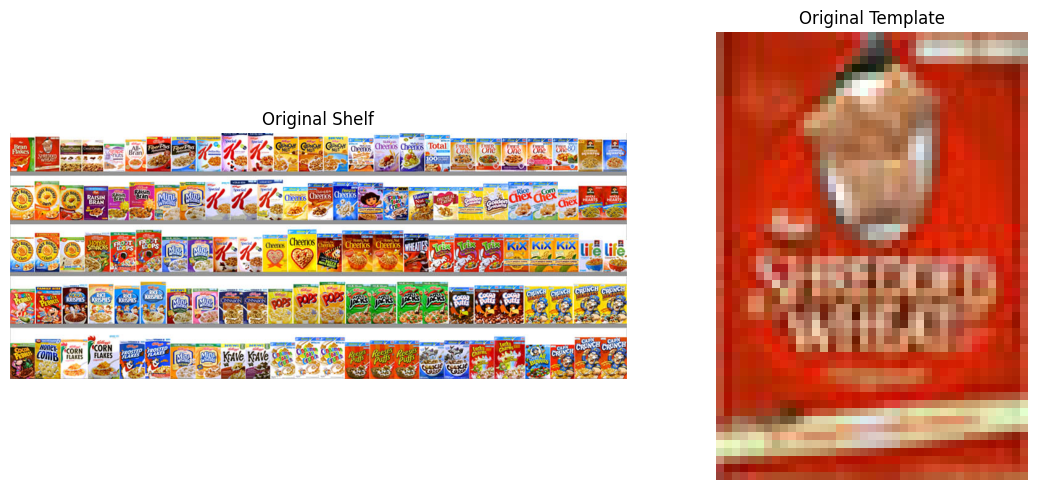

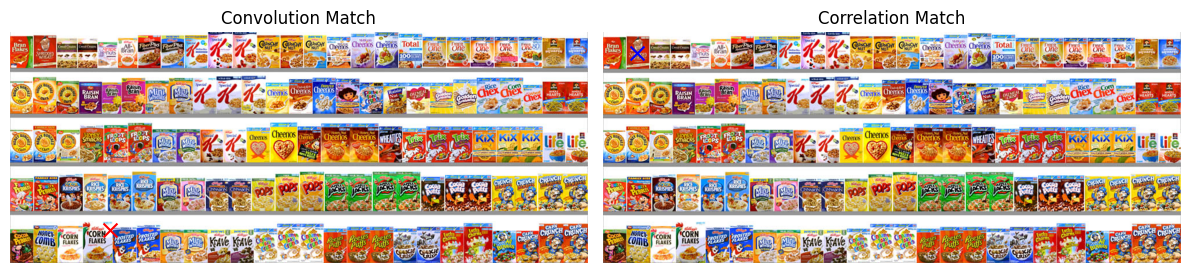

Convolution detected product at (x, y): (np.int64(153), np.int64(314))
Correlation detected product at (x, y): (np.int64(41), np.int64(8))


In [57]:
shelf = np.load(r"C:\Ali\Programming\DlpSpring26\A01\shelf.npy")       # e.g., shape (400, 600)
template = np.load(r"C:\Ali\Programming\DlpSpring26\A01\template.npy") # e.g., shape (50, 50)

shelf = shelf.astype(float)
template = template.astype(float)

# Convert to grayscale if color (3D) image
if shelf.ndim == 3:
    shelf_gray = shelf.mean(axis=2)
else:
    shelf_gray = shelf

if template.ndim == 3:
    template_gray = template.mean(axis=2)
else:
    template_gray = template

# Display original shelf and template images separately
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(shelf.astype(np.uint8))
axes[0].set_title("Original Shelf")
axes[0].axis("off")

axes[1].imshow(template.astype(np.uint8))
axes[1].set_title("Original Template")
axes[1].axis("off")

plt.tight_layout()
plt.show()

shelf_norm = normalize_image(shelf_gray)
template_norm = normalize_image(template_gray)


conv_result = convolve2d(shelf_norm, template_norm)
conv_x, conv_y = locate_product(conv_result)


corr_result = correlate2d(shelf_norm, template_norm)
corr_x, corr_y = locate_product(corr_result)


# Display convolution and correlation match results separately
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(shelf.astype(np.uint8))
axes[0].set_title("Convolution Match")
axes[0].scatter(conv_x + template.shape[1]//2, conv_y + template.shape[0]//2, c='r', s=100, marker='x')
axes[0].axis('off')

axes[1].imshow(shelf.astype(np.uint8))
axes[1].set_title("Correlation Match")
axes[1].scatter(corr_x + template.shape[1]//2, corr_y + template.shape[0]//2, c='b', s=100, marker='x')
axes[1].axis('off')

plt.tight_layout()
plt.show()


print("Convolution detected product at (x, y):", (conv_x, conv_y))
print("Correlation detected product at (x, y):", (corr_x, corr_y))
